In [1]:
import numpy as np
import matplotlib.pylab as plt

C:\Users\carlos\AppData\Local\Temp\ipykernel_19508\2858609768.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


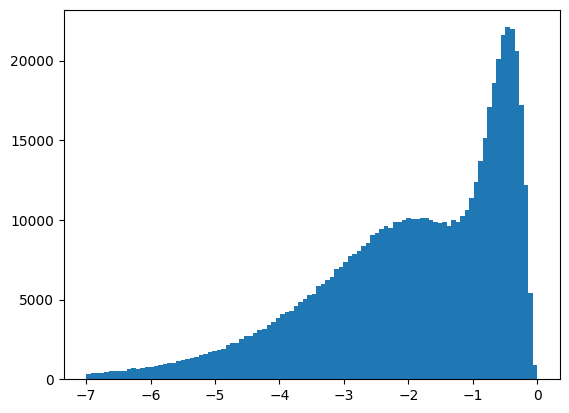

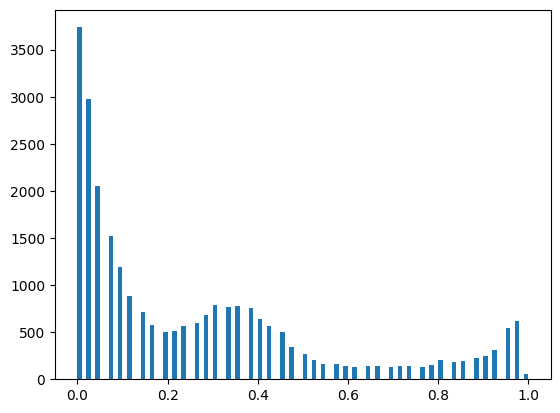

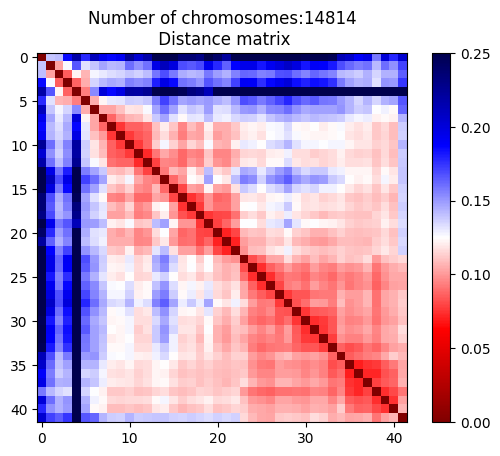

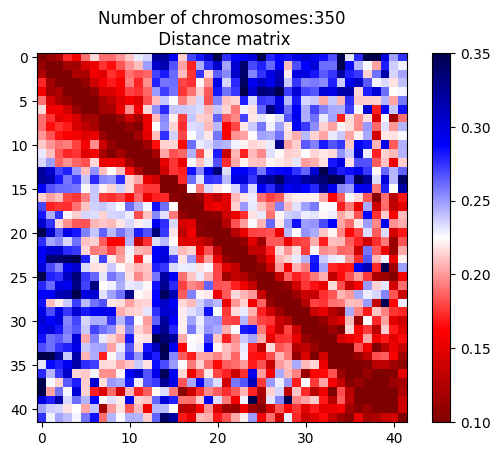

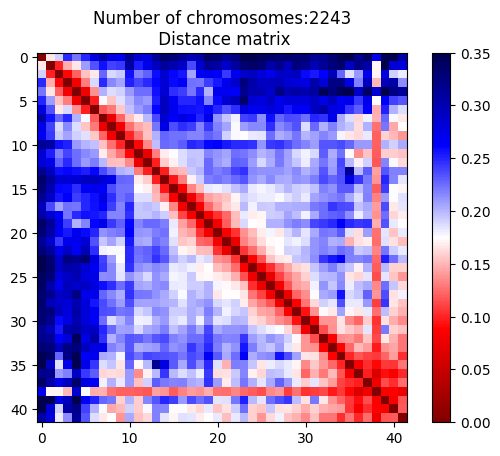

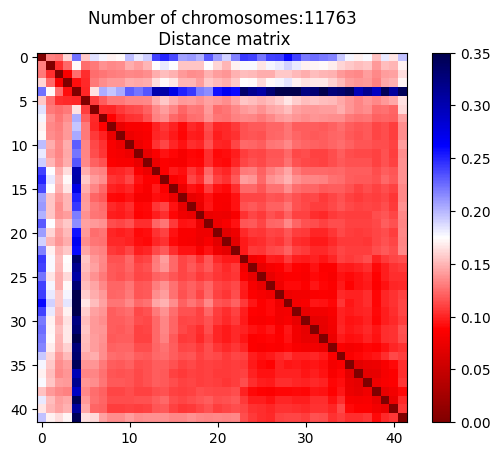

In [2]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D157KO_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.5]=np.nan ######################################## Adjusting originally 1
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D120 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0,vmax=0.25)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep6],axis=0),cmap='seismic_r',vmin=0,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keepN],axis=0),cmap='seismic_r',vmin=0,vmax=0.35)
plt.colorbar()

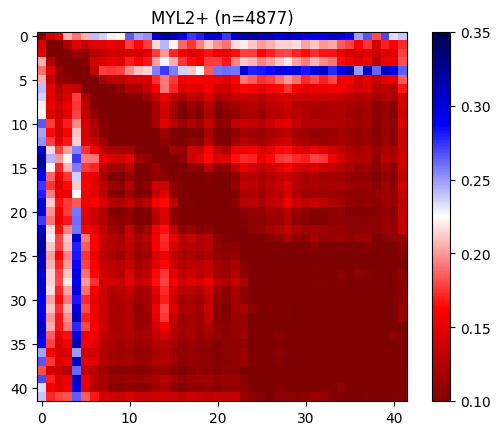

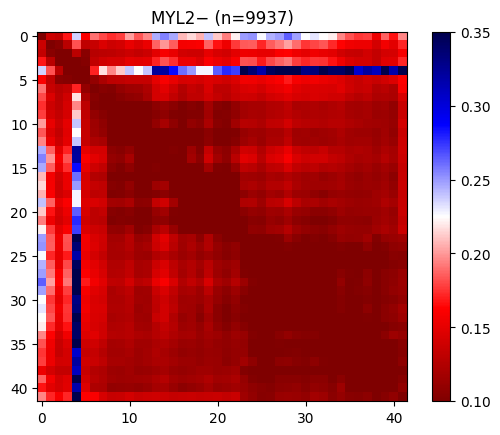

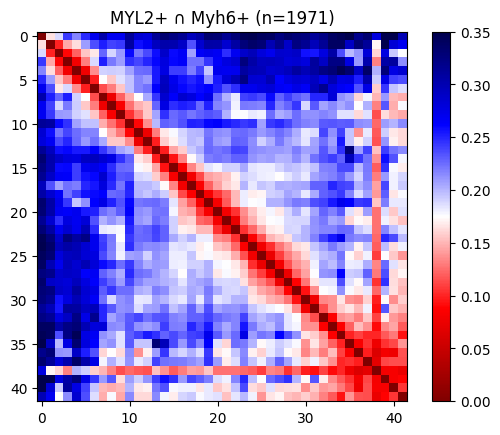

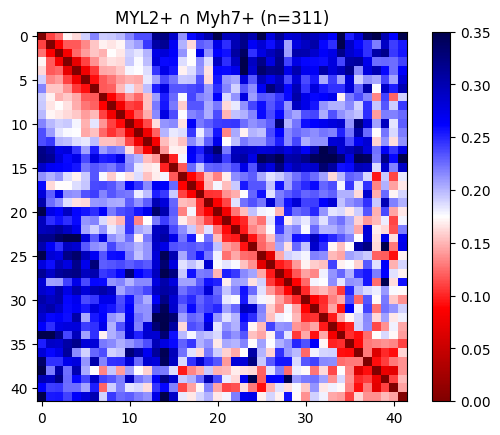

In [3]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D120_myl2)})")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D120_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D120_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D120_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h7, axis=0), cmap='seismic_r', vmin=0, vmax=0.35)
plt.colorbar()

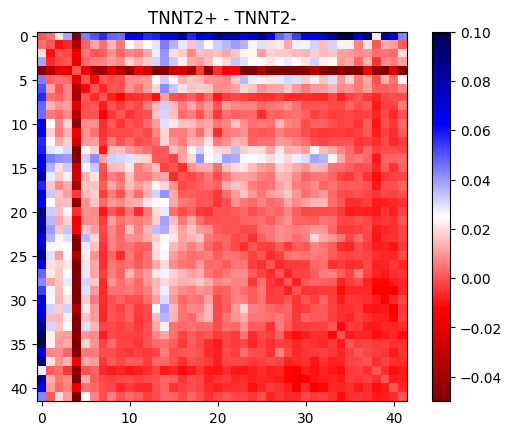

In [4]:
plt.figure()
plt.title(f"TNNT2+ - TNNT2-")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0)-np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.05, vmax=0.1)
plt.colorbar()

In [5]:
med_D120 = np.nanmedian(mats_D120,axis=0)


C:\Users\carlos\AppData\Local\Temp\ipykernel_19508\2514482759.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


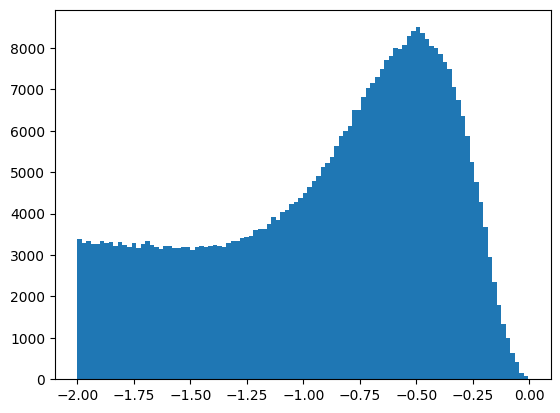

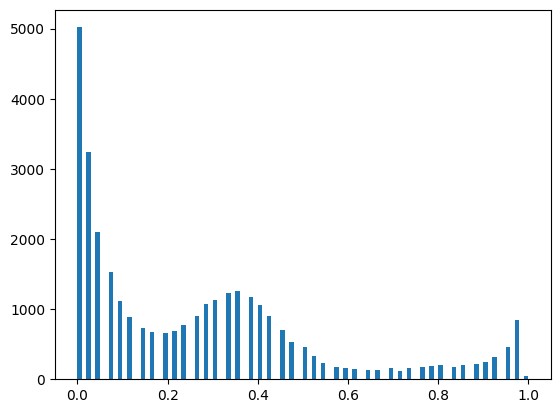

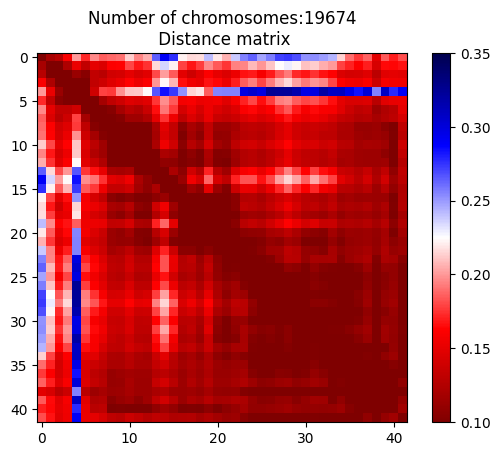

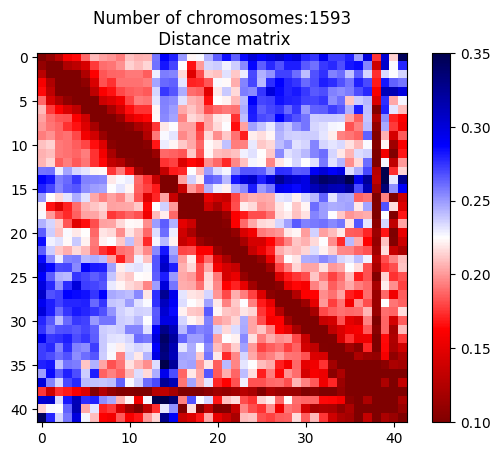

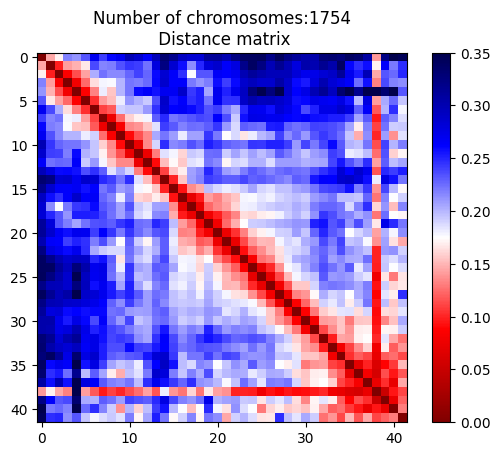

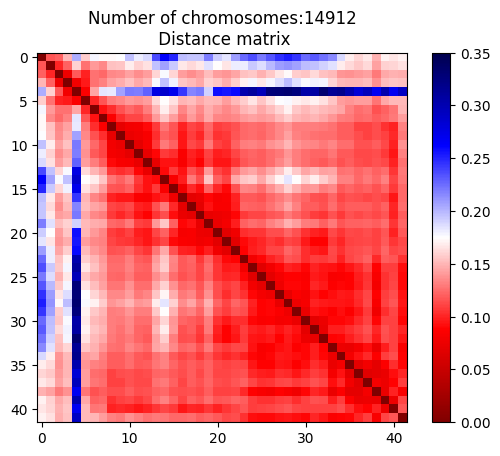

In [6]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D157WT_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-2]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.5]=np.nan ######################### originally 1
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D104 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep6],axis=0),cmap='seismic_r',vmin=0,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keepN],axis=0),cmap='seismic_r',vmin=0,vmax=0.35)
plt.colorbar()

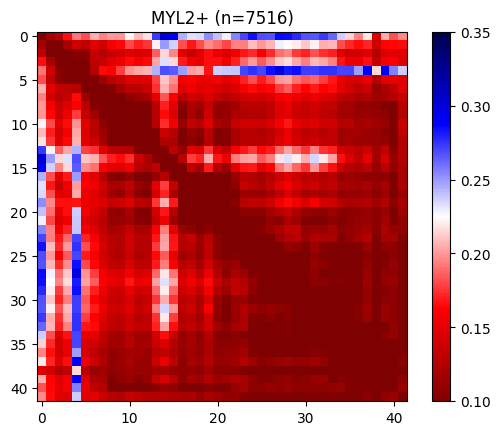

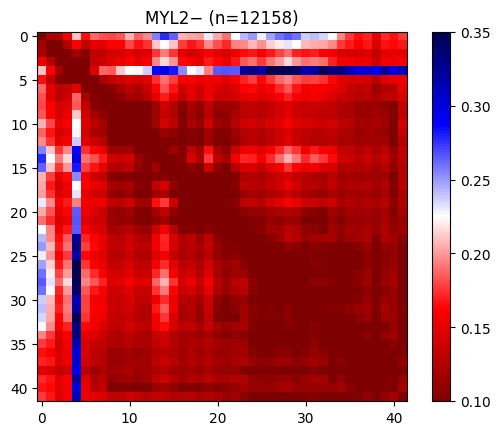

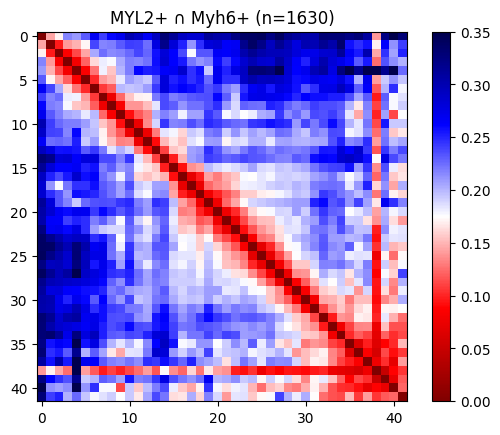

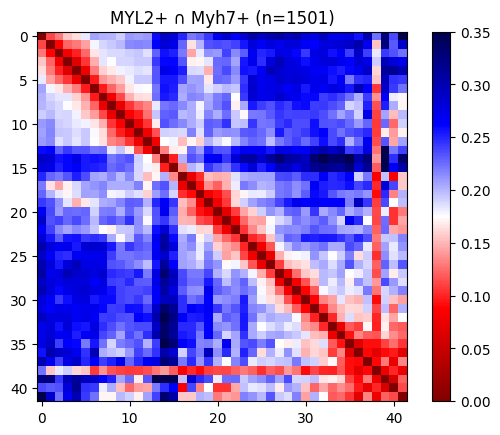

In [7]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D104_myl2)})")
plt.imshow(np.nanmedian(mats_D104_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D104_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D104_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0), cmap='seismic_r', vmin=0, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D104_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0), cmap='seismic_r', vmin=0, vmax=0.35)
plt.colorbar()

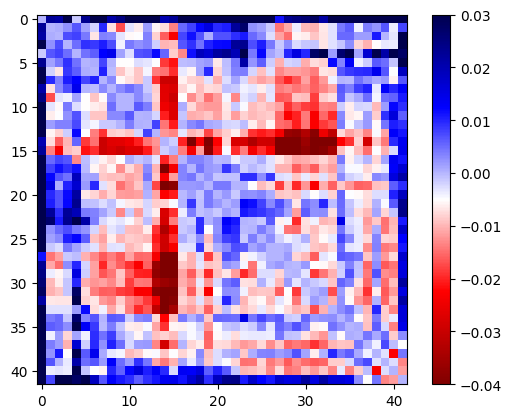

In [8]:
plt.figure()
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0)-np.nanmedian(mats_D104_myl2, axis=0), cmap='seismic_r', vmin=-0.04 , vmax=0.03)
plt.colorbar()

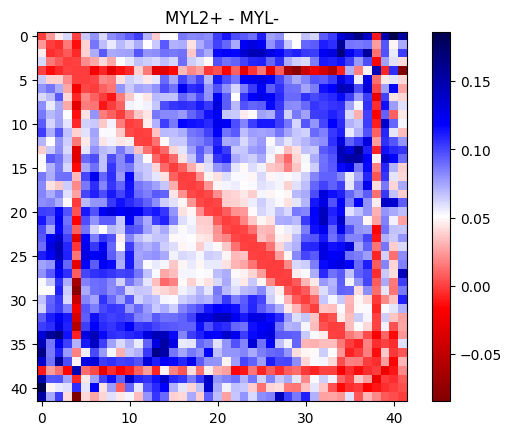

In [9]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0)-np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r')
plt.colorbar()

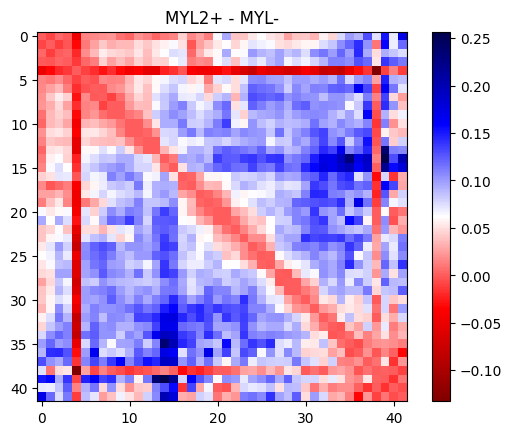

In [10]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0)-np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r')
plt.colorbar()

In [11]:

med_D104 = np.nanmedian(mats_D104,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104_keep7 = np.nanmedian(mats_D104[keep7],axis=0)
med_D104_keep6 = np.nanmedian(mats_D104[keep6],axis=0)
med_D104_keepN = np.nanmedian(mats_D104[keepN],axis=0)

NameError: name 'mats_D118' is not defined

In [ ]:
dth = 0.15

plt.figure()
plt.title(f"MYL2+ D80 delta5KO")
mat_delta_myl2 = np.sum(mats_D120_myl2[:]<dth,axis=0)/np.sum(mats_D120_myl2[:]>=0,axis=0)
plt.imshow(np.log(mat_delta_myl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2- D80 delta5KO")
mat_delta_nonmyl2 = np.sum(mats_D120_nonmyl2[:]<dth,axis=0)/np.sum(mats_D120_nonmyl2[:]>=0,axis=0)
plt.imshow(np.log(mat_delta_nonmyl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2+ D80 WT")
mat_wt_myl2 = np.sum(mats_D104_myl2[:]<dth,axis=0)/np.sum(mats_D104_myl2[:]>=0,axis=0)
plt.imshow(np.log(mat_wt_myl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2- D80 WT")
mat_wt_nonmyl2 = np.sum(mats_D104_nonmyl2[:]<dth,axis=0)/np.sum(mats_D104_nonmyl2[:]>=0,axis=0)
plt.imshow(np.log(mat_wt_nonmyl2),cmap='seismic')

In [ ]:
plt.imshow(np.log(mat_delta_myl2)/np.log(mat_delta_nonmyl2),cmap='seismic', vmin=1, vmax = 1.5)
plt.colorbar()

In [7]:
data = [med_D120_keep.ravel()/med_D104_keep7.ravel(),med_D120_keep.ravel()/med_D104_keep6.ravel(),med_D120_keep.ravel()/med_D104_keepN.ravel(),med_D120_keep.ravel()/med_D118.ravel()]
data = [d[~np.isnan(d)]for d in data]

C:\Users\Carlos\AppData\Local\Temp\ipykernel_15760\3297490314.py:1: RuntimeWarning: invalid value encountered in divide
  data = [med_D120.ravel()/med_D104_keep7.ravel(),med_D120.ravel()/med_D104_keep6.ravel(),med_D120.ravel()/med_D104_keepN.ravel(),med_D120.ravel()/med_D118.ravel()]


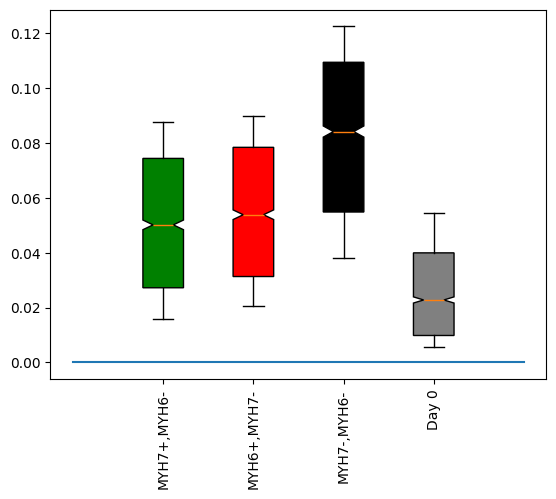

In [10]:
data = np.abs([med_D120_keep.ravel()-med_D104_keep7.ravel(),med_D120_keep.ravel()-med_D104_keep6.ravel(),med_D120_keep.ravel()-med_D104_keepN.ravel(),med_D120_keep.ravel()-med_D118.ravel()])
data = [d[~np.isnan(d)]for d in data]
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[0,0])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

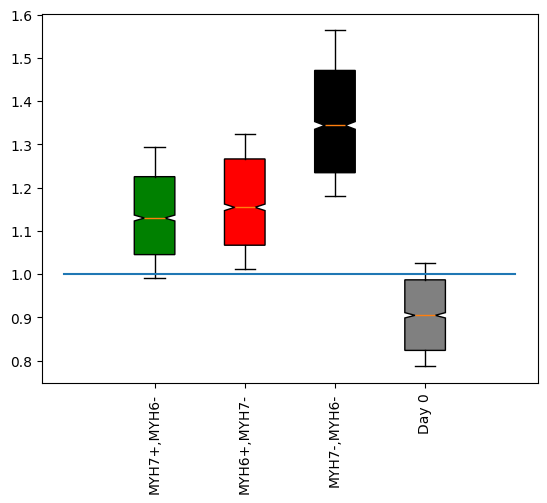

In [8]:
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[1,1])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

In [17]:
# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 9498 but corresponding boolean dimension is 13341

In [12]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.75):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [13]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p = get_random_maps(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100,dth=0.07)
# mats_D120_m = get_random_maps(mats_D120_nonmyl2,np.arange(len(mats_D120_nonmyl2)),N=100,dth=0.75)
mats_D104_p = get_random_maps(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100,dth=0.07)
# mats_D104_m = get_random_maps(mats_D104_nonmyl2,np.arange(len(mats_D104_nonmyl2)),N=100,dth=0.75)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 17.49it/s]


In [13]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p_h6 = get_random_maps(mats_D120_myl2_h6,np.arange(len(mats_D120_myl2_h6)),N=100,dth=0.1)
mats_D120_p_h7 = get_random_maps(mats_D120_myl2_h7,np.arange(len(mats_D120_myl2_h7)),N=100,dth=0.1)
mats_D104_p_h6 = get_random_maps(mats_D104_myl2_h6,np.arange(len(mats_D104_myl2_h6)),N=100,dth=0.1)
mats_D104_p_h7 = get_random_maps(mats_D104_myl2_h7,np.arange(len(mats_D104_myl2_h7)),N=100,dth=0.1)

  7%|█████▋                                                                            | 7/100 [00:00<00:01, 64.79it/s]C:\Users\Carlos\AppData\Local\Temp\ipykernel_34912\1803991129.py:5: RuntimeWarning: invalid value encountered in divide
  med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 86.19it/s]


# Figure i

Rank-sum p-value between KO and WT: 2.52e-34


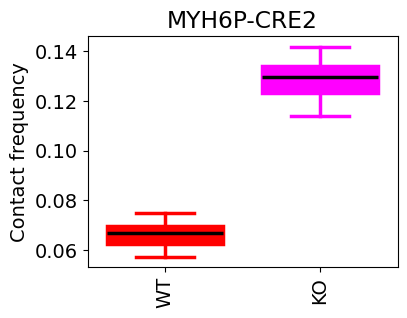

In [29]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [13, 28]
line_width = 2.5

# Extract data
X = mats_D120_p[:, i1, i2]
Z = mats_D104_p[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between KO and WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['WT', 'KO'], rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4_{i1}_{i2}_D157.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between KO and WT: 2.52e-34


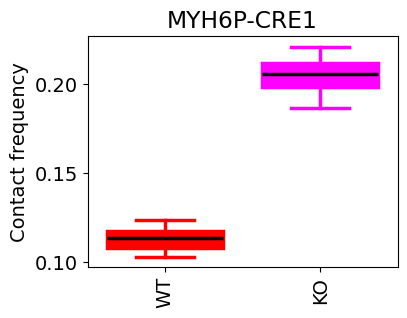

In [30]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [13, 31]
line_width = 2.5

# Extract data
X = mats_D120_p[:, i1, i2]
Z = mats_D104_p[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between KO and WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['WT', 'KO'], rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4_{i1}_{i2}_D157.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between KO and WT: 2.52e-34


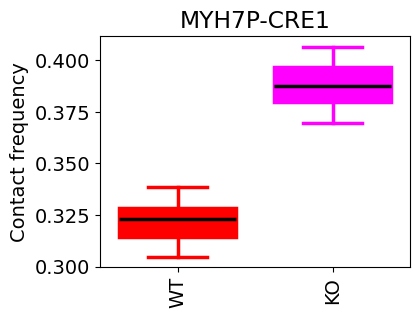

In [31]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [27, 31]
line_width = 2.5

# Extract data
X = mats_D120_p[:, i1, i2]
Z = mats_D104_p[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between KO and WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['WT', 'KO'], rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4_{i1}_{i2}_D157.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

In [17]:
import numpy as np
from tqdm import tqdm

def get_random_med(mats, iDNA7_, N=100):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        # sample with replacement
        iRand = np.random.randint(0, len(iDNA7_), len(iDNA7_))
        # take subset and compute nanmedian along axis=0
        med_7_C = np.nanmedian(mats[iDNA7_[iRand]], axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [18]:
mats_D120_med = get_random_med(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100)
mats_D104_med = get_random_med(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:18<00:00,  5.36it/s]


Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


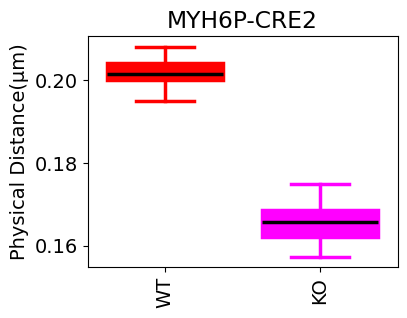

In [26]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['WT', 'KO'], rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Physical Distance(µm)")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4_{i1}_{i2}_D157_distance.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


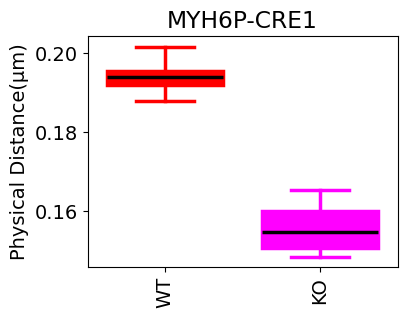

In [27]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['WT', 'KO'], rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Physical Distance(µm)")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4_{i1}_{i2}_D157_distance.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between D15 DKO and D15 WT: 5.03e-34


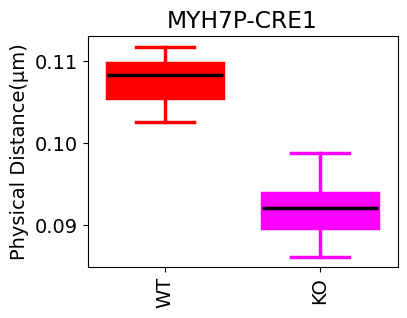

In [28]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['WT', 'KO'], rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Physical Distance(µm)")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4_{i1}_{i2}_D157_distance.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Contact frequency')

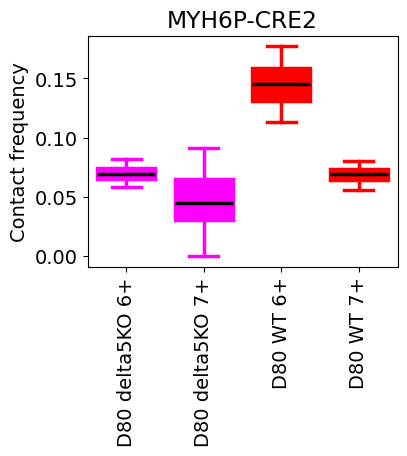

In [84]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p_h6[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D120_p_h7[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Y = mats_D104_p_h7[:,i1,i2]
box_Y = ax.boxplot(Y, positions=[0.6], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.7])
plt.xticks([0,0.2,0.4, 0.6],['D80 delta5KO 6+', 'D80 delta5KO 7+','D80 WT 6+','D80 WT 7+'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

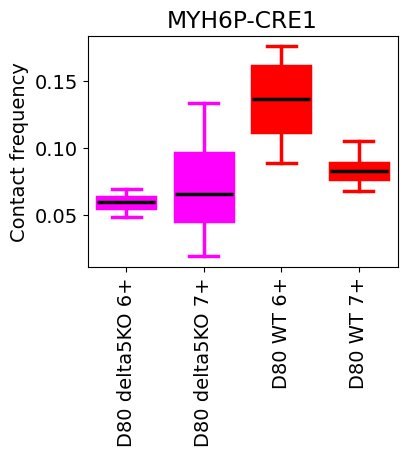

In [85]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p_h6[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D120_p_h7[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Y = mats_D104_p_h7[:,i1,i2]
box_Y = ax.boxplot(Y, positions=[0.6], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.7])
plt.xticks([0,0.2,0.4, 0.6],['D80 delta5KO 6+', 'D80 delta5KO 7+','D80 WT 6+','D80 WT 7+'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

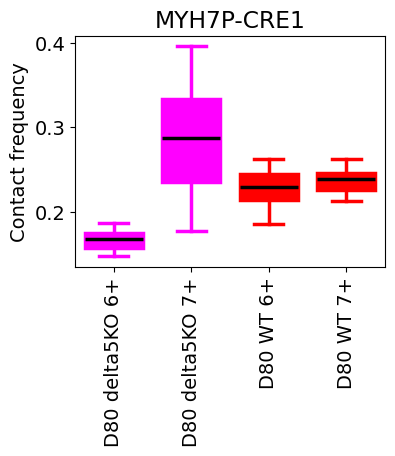

In [86]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p_h6[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D120_p_h7[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Y = mats_D104_p_h7[:,i1,i2]
box_Y = ax.boxplot(Y, positions=[0.6], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.7])
plt.xticks([0,0.2,0.4, 0.6],['D80 delta5KO 6+', 'D80 delta5KO 7+','D80 WT 6+','D80 WT 7+'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\2085552967.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

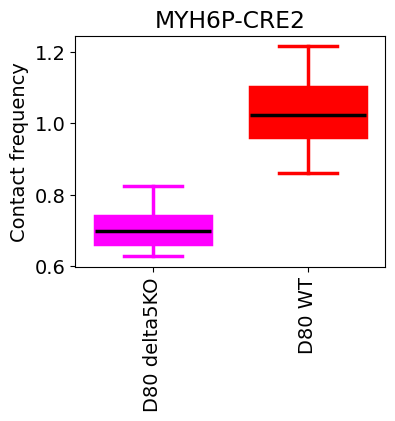

In [80]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 delta5KO','D80 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\3537173388.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = np.log(mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

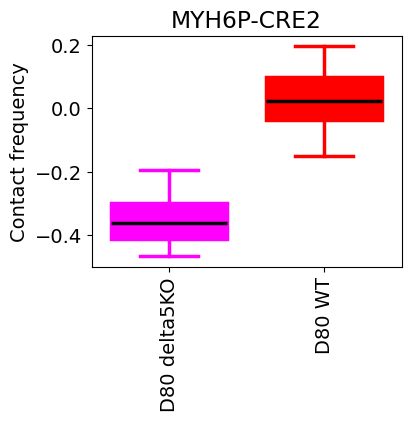

In [79]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = np.log(mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = np.log(mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 delta5KO','D80 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\3150344836.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

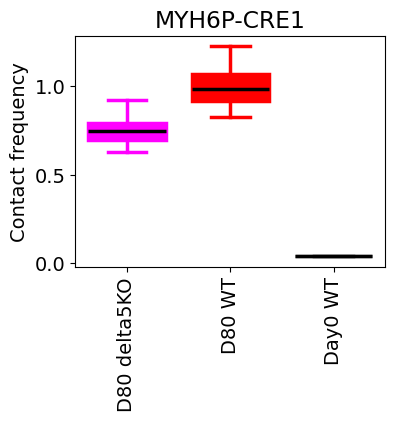

In [70]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\130861578.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

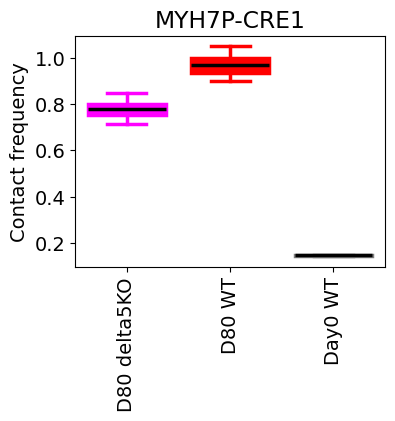

In [72]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

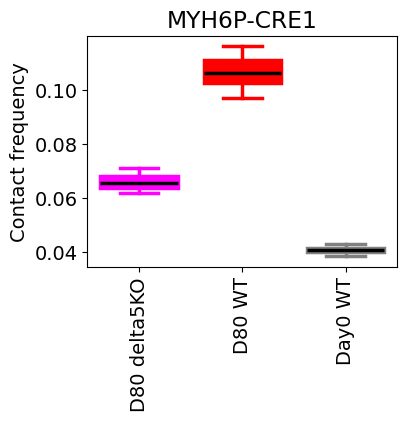

In [18]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

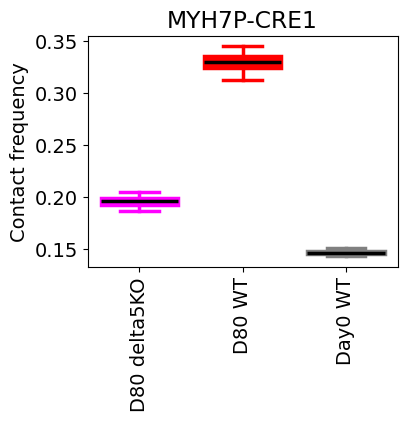

In [19]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))
# X = mats_D103_6[:,i1,i2]
# box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
#                    boxprops=dict(facecolor='red', color='red',linewidth=line_width),
#                    whiskerprops=dict(color='red',linewidth=line_width),
#                    capprops=dict(color='red',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# # Box plot for Y in green
# Y = mats_D103_7[:,i1,i2]
# box_Y = ax.boxplot(Y, positions=[0.2], patch_artist=True, 
#                    boxprops=dict(facecolor='green', color='green',linewidth=line_width),
#                    whiskerprops=dict(color='green',linewidth=line_width),
#                    capprops=dict(color='green',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

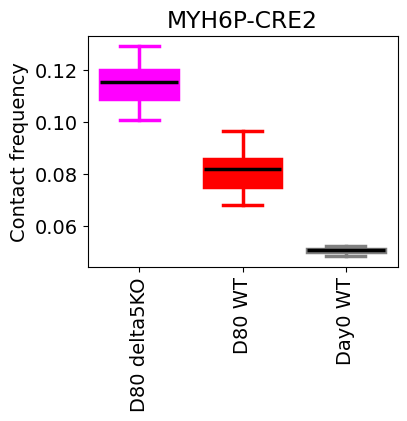

In [20]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

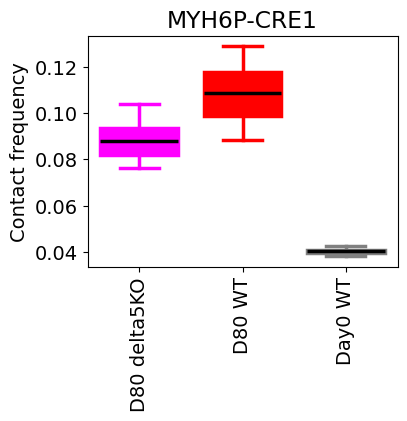

In [21]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

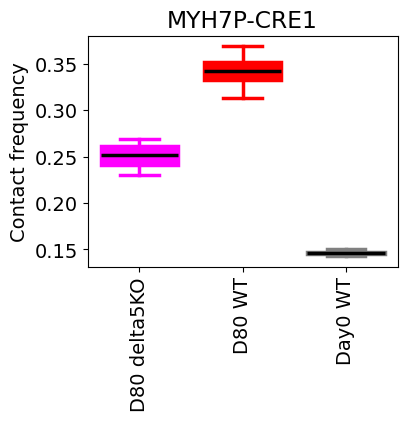

In [22]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")